# Aggregation Global Analysis

In [1]:
def default_params(): 
    return {
        'current_model': 'M1', 
        'quantization': 'none', #['none',"int4", "int8", "float32", "float16"]
        'dataset': {
            'name': '/workspaces/CodeSmells/semeru-datasets/code_smells/codesmell_dataset.csv',
            'content_column': 'code',
        },
        'bootstrapping_size':100000,
        'output_path' : '../data/global_analysis',
        'logits_path': '../data/raw_logits',
        'aggregation_path': '../data/aligned_tokens',
        'preprocessed_dataset_dir' : '../datax/code_smells/dataset_preprocessing',
        'cache_dir': '../datax/hugging_face_cache',
        'causal_models': {
            'M1': 'codellama/CodeLlama-7b-hf', #https://huggingface.co/codellama/CodeLlama-7b-hf, 
            'M2': 'mistralai/Mistral-7B-v0.3', #https://huggingface.co/codellama/CodeLlama-13b-hf,
        },
        'top-k': 21
    }
params = default_params()


#### Imports

In [2]:
import pandas as pd
import os
import time
import numpy as np
from datasets import load_dataset 
from statistics import mean, median
import json
import torch
import gc

In [3]:
import seaborn as sns; sns.set_theme()
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.backends.backend_pdf import PdfPages

In [4]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox

#### Boostrapping

In [5]:
#| export
def bootstrapping( np_data, np_func, size ):
    """Create a bootstrap sample given data and a function
    For instance, a bootstrap sample of means, or mediands. 
    The bootstrap replicates are a long as the original size
    we can choose any observation more than once (resampling with replacement:np.random.choice)
    """
    
    #Cleaning NaNs
    #np_data_clean = np_data[ np.logical_not( np.isnan(np_data) ) ] 
    
    #The size of the bootstrap replicate is as big as size
    #Creating the boostrap replicates as long as the orignal data size
    #This strategy might work as imputation 
    bootstrap_repl = [ np_func( np.random.choice( np_data, size=len(np_data) ) ) for i in range( size ) ]
    
    #logging.info("Covariate: " + cov) #Empirical Mean
    #logging.info("Empirical Mean: " + str(np.mean(np_data_clean))) #Empirical Mean
    #logging.info("Bootstrapped Mean: " + str( np.mean(bootstrap_repl) ) ) #Bootstrapped Mean
    
    return np.array( bootstrap_repl )

#### Load Aggregates

In [6]:
df_actual_ntp = pd.read_csv(params['aggregation_path'] + '/' + params['current_model'] + '_q_' + params['quantization'] + '/' + 'aligned_smells.csv', index_col=0)

In [7]:
df_actual_ntp.head(3)

,msg_id,code_smell,code,func_name,commit_id,repo,path,url,language,n_ast_errors,...,code_smell_pos,code_smell_actual_logits,code_smell_max_logits,code_smell_min_logits,code_smell_actual_prob_median,code_smell_max_prob_median,code_smell_min_prob_median,code_smell_actual_prob_mean,code_smell_max_prob_mean,code_smell_min_prob_mean
0,C0103,"A = [1, 2, 3, 3]",def test_array_sum_combinations(self):\n ...,test_array_sum_combinations,87eae9a25751a13d4ef48860fffa4df0998356eb,algorithms,tests\test_backtrack.py,https://github.com/keon/algorithms.git,Python,0,...,"(47, 63)","[('A', 0.005719942040741444), ('=', 0.93573218...","[('""""""', 0.23746822774410248), ('=', 0.9357321...","[('protected', 6.071649259753453e-12), ('ackno...",0.733365,0.769212,4.392644e-14,0.639321,0.727410,7.758914e-13
1,C0103,"B = [2, 3, 3, 4]",def test_array_sum_combinations(self):\n ...,test_array_sum_combinations,87eae9a25751a13d4ef48860fffa4df0998356eb,algorithms,tests\test_backtrack.py,https://github.com/keon/algorithms.git,Python,0,...,"(72, 88)","[('B', 0.1225515678524971), ('=', 0.9945827126...","[('assert', 0.1824035793542862), ('=', 0.99458...","[('abstract', 1.925486029299983e-12), ('Arn', ...",0.825810,0.825810,3.349158e-14,0.698608,0.748402,2.260894e-13
2,C0103,"C = [2, 3, 3, 4]",def test_array_sum_combinations(self):\n ...,test_array_sum_combinations,87eae9a25751a13d4ef48860fffa4df0998356eb,algorithms,tests\test_backtrack.py,https://github.com/keon/algorithms.git,Python,0,...,"(97, 113)","[('C', 0.30543676018714905), ('=', 0.991418719...","[('C', 0.30543676018714905), ('=', 0.991418719...","[('Icon', 4.609939600191959e-12), ('ightarrow'...",0.902062,0.902062,2.560742e-14,0.759447,0.768921,6.434997e-13


In [8]:
len(df_actual_ntp)

77107

### Global Analysis (Code Smells)

In [9]:
## Filter Code Smells by precission > 0.9 
inclusion_list = ['W3601', 'W0718', 'W0719', 'R1716', 'R0124', 'R1701', 'C0104', 'W0130', 'W1508', 
                'R0123', 'W0150', 'W4701', 'C0103', 'W3301', 'C2401', 'R1726', 'C0121', 'R0913', 
                'R0916', 'R1702', 'W0644', 'C3002', 'C3001', 'W0108', 'W0101']
df_actual_ntp = df_actual_ntp[df_actual_ntp['msg_id'].isin(inclusion_list)]
df_actual_ntp = df_actual_ntp.reset_index(drop=True)

In [10]:
df_actual_ntp

,msg_id,code_smell,code,func_name,commit_id,repo,path,url,language,n_ast_errors,...,code_smell_pos,code_smell_actual_logits,code_smell_max_logits,code_smell_min_logits,code_smell_actual_prob_median,code_smell_max_prob_median,code_smell_min_prob_median,code_smell_actual_prob_mean,code_smell_max_prob_mean,code_smell_min_prob_mean
0,C0103,"A = [1, 2, 3, 3]",def test_array_sum_combinations(self):\n ...,test_array_sum_combinations,87eae9a25751a13d4ef48860fffa4df0998356eb,algorithms,tests\test_backtrack.py,https://github.com/keon/algorithms.git,Python,0,...,"(47, 63)","[('A', 0.005719942040741444), ('=', 0.93573218...","[('""""""', 0.23746822774410248), ('=', 0.9357321...","[('protected', 6.071649259753453e-12), ('ackno...",0.733365,0.769212,4.392644e-14,0.639321,0.727410,7.758914e-13
1,C0103,"B = [2, 3, 3, 4]",def test_array_sum_combinations(self):\n ...,test_array_sum_combinations,87eae9a25751a13d4ef48860fffa4df0998356eb,algorithms,tests\test_backtrack.py,https://github.com/keon/algorithms.git,Python,0,...,"(72, 88)","[('B', 0.1225515678524971), ('=', 0.9945827126...","[('assert', 0.1824035793542862), ('=', 0.99458...","[('abstract', 1.925486029299983e-12), ('Arn', ...",0.825810,0.825810,3.349158e-14,0.698608,0.748402,2.260894e-13
2,C0103,"C = [2, 3, 3, 4]",def test_array_sum_combinations(self):\n ...,test_array_sum_combinations,87eae9a25751a13d4ef48860fffa4df0998356eb,algorithms,tests\test_backtrack.py,https://github.com/keon/algorithms.git,Python,0,...,"(97, 113)","[('C', 0.30543676018714905), ('=', 0.991418719...","[('C', 0.30543676018714905), ('=', 0.991418719...","[('Icon', 4.609939600191959e-12), ('ightarrow'...",0.902062,0.902062,2.560742e-14,0.759447,0.768921,6.434997e-13
3,C0103,"A = [1, 2, 3, 3]",def test_unique_array_sum_combinations(self):\...,test_unique_array_sum_combinations,87eae9a25751a13d4ef48860fffa4df0998356eb,algorithms,tests\test_backtrack.py,https://github.com/keon/algorithms.git,Python,0,...,"(54, 70)","[('A', 0.0039241560734808445), ('=', 0.9402759...","[('""""""', 0.21724160015583038), ('=', 0.9402759...","[('decl', 2.486116781191816e-12), ('acknowled'...",0.735142,0.735142,2.192054e-14,0.652295,0.707267,3.427358e-13
4,C0103,"B = [2, 3, 3, 4]",def test_unique_array_sum_combinations(self):\...,test_unique_array_sum_combinations,87eae9a25751a13d4ef48860fffa4df0998356eb,algorithms,tests\test_backtrack.py,https://github.com/keon/algorithms.git,Python,0,...,"(79, 95)","[('B', 0.14950056374073029), ('=', 0.994486033...","[('B', 0.14950056374073029), ('=', 0.994486033...","[('abstract', 1.4967290644721243e-12), ('!}', ...",0.799778,0.799778,1.649570e-14,0.695196,0.740536,1.426003e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75548,R0913,"def _call_api(self, path, display_id, note='Do...","def _call_api(self, path, display_id, note='Do...",_call_api,0d067e77c3f5527946fb0c22ee1c7011994cba40,yt-dlp,yt_dlp\extractor\dangalplay.py,https://github.com/yt-dlp/yt-dlp.git,Python,0,...,"(0, 94)","[('def', 0.0007611332111991942), ('_', 0.00901...","[('<PRE>', 0.7492897510528564), ('module', 0.4...","[('<s>', 6.321804516505602e-13), ('$}', 1.2101...",0.058301,0.577129,4.880852e-13,0.332025,0.536023,8.291104e-12
75549,C0103,"for ep in traverse_obj(data, ('data', 'items',...","def _entries(self, subcategories, series_slug)...",_entries,0d067e77c3f5527946fb0c22ee1c7011994cba40,yt-dlp,yt_dlp\extractor\dangalplay.py,https://github.com/yt-dlp/yt-dlp.git,Python,0,...,"(437, 516)","[('ep', 0.020490219816565514), ('in', 0.758157...","[('entry', 0.36265790462493896), ('in', 0.7581...","[('destroy', 1.4244970220761433e-12), ('();`',...",0.438482,0.645477,1.260584e-13,0.466640,0.615913,3.457094e-13
75550,C0103,"qs = {k: v[-1] for k, v in parse_qs(url).items...","def _real_extract(self, url, html=None):\n ...",_real_extract,a4da9db87b6486b270c15dfa07ab5bfedc83f6bd,yt-dlp,yt_dlp\extractor\youporn.py,https://github.com/yt-dlp/yt-dlp.git,Python,0,...,"(186, 240)","[('q', 0.0026826527900993824), 

In [11]:
df_actual_ntp['msg_id'].unique()

array(['C0103', 'R0916', 'W0719', 'W3301', 'R0913', 'C0104', 'W0718',
       'C0121', 'W0108', 'R1701', 'C3001', 'R1716', 'C3002', 'W0101',
       'R0123', 'R0124', 'W3601', 'R1702', 'W0150', 'W4701', 'C2401',
       'R1726', 'W0130', 'W0644'], dtype=object)

In [12]:
def transform_z_score(data_values):
    scaler = StandardScaler()
    return scaler.fit_transform(np.array(data_values).reshape(-1, 1)).flatten()

In [13]:
def transform_boxcox(data_values):
    transformed_data, lambda_value = boxcox(data_values)
    return transformed_data

In [14]:
top_smells = df_actual_ntp['msg_id'].value_counts().head(params['top-k']).index.tolist()

In [15]:
df_actual_ntp['msg_id'].value_counts().head(1)

msg_id
C0103    68573
Name: count, dtype: int64

#### Compute distributions DFs

In [16]:
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [17]:
def create_distribution_pandas(df_actual_ntp):
    actual_probs_distributions = {
        'code_smell_actual_prob' : np.concatenate([df_actual_ntp[df_actual_ntp['msg_id']==msg_id]['code_smell_actual_prob_mean'].tolist() for msg_id in top_smells]), 
        'msg_id' : np.concatenate([[msg_id] * len(df_actual_ntp[df_actual_ntp['msg_id']==msg_id]) for msg_id in top_smells]), 
        'model': np.concatenate([[params['current_model']] * len(df_actual_ntp[df_actual_ntp['msg_id']==msg_id]) for msg_id in top_smells])}
    actual_probs_distributions_snormal = {
        'code_smell_actual_prob' : np.concatenate([transform_z_score(actual_probs_distributions['code_smell_actual_prob'])]), 
        'msg_id' : actual_probs_distributions['msg_id'], 
        'model' : actual_probs_distributions['model']}    
    actual_probs_distributions_boxcox = {
        'code_smell_actual_prob' : np.concatenate([transform_boxcox(actual_probs_distributions['code_smell_actual_prob'])]), 
        'msg_id' : actual_probs_distributions['msg_id'], 
        'model' : actual_probs_distributions['model']}
    actual_probs_distributions_boostrapped = {
        'code_smell_actual_prob' : np.concatenate([bootstrapping(df_actual_ntp[df_actual_ntp['msg_id']==msg_id]['code_smell_actual_prob_mean'].tolist(), np.mean, params['bootstrapping_size']) for msg_id in top_smells]), 
        'msg_id' : np.concatenate([[msg_id] * params['bootstrapping_size'] for msg_id in top_smells]),
        'model' : np.concatenate([[params['current_model']] * params['bootstrapping_size'] for msg_id in top_smells])}
    actual_probs_distributions_boostrapped_boxcox = {
        'code_smell_actual_prob' : np.concatenate([transform_boxcox(actual_probs_distributions_boostrapped['code_smell_actual_prob'])]), 
        'msg_id' : actual_probs_distributions_boostrapped['msg_id'],
        'model' : actual_probs_distributions_boostrapped['model']}
    actual_probs_distributions_boostrapped_snormal = {
        'code_smell_actual_prob' : np.concatenate([transform_z_score(actual_probs_distributions_boostrapped['code_smell_actual_prob'])]), 
        'msg_id' : actual_probs_distributions_boostrapped['msg_id'],
        'model' : actual_probs_distributions_boostrapped['model']}
    ##### SAVE
    create_folder(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}")
    pd.DataFrame(actual_probs_distributions).to_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_top{params['top-k']}")
    pd.DataFrame(actual_probs_distributions_snormal).to_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_snormal_top{params['top-k']}")
    pd.DataFrame(actual_probs_distributions_boxcox).to_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_boxcox_top{params['top-k']}")
    pd.DataFrame(actual_probs_distributions_boostrapped).to_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_boostrapped_top{params['top-k']}")
    pd.DataFrame(actual_probs_distributions_boostrapped_boxcox).to_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_boostrapped_boxcox_top{params['top-k']}")
    pd.DataFrame(actual_probs_distributions_boostrapped_snormal).to_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_boostrapped_snormal_top{params['top-k']}")

    

In [18]:
#create_distribution_pandas(df_actual_ntp)

In [19]:
actual_probs_distributions = pd.read_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_top{params['top-k']}", index_col=0)
actual_probs_distributions_snormal = pd.read_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_snormal_top{params['top-k']}", index_col=0)
actual_probs_distributions_boxcox = pd.read_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_boxcox_top{params['top-k']}", index_col=0)

actual_probs_distributions_boostrapped = pd.read_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_boostrapped_top{params['top-k']}", index_col=0)
actual_probs_distributions_boostrapped_boxcox = pd.read_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_boostrapped_boxcox_top{params['top-k']}", index_col=0)
actual_probs_distributions_boostrapped_snormal = pd.read_csv(f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}/actual_probs_distributions_boostrapped_snormal_top{params['top-k']}", index_col=0)

#### Plots

[Text(0.5, 0, 'probability'),
 Text(0, 0.5, 'code_smell'),
 Text(0.5, 1.0, 'Distribution of top-21 Code Smells using codellama/CodeLlama-7b-hf')]

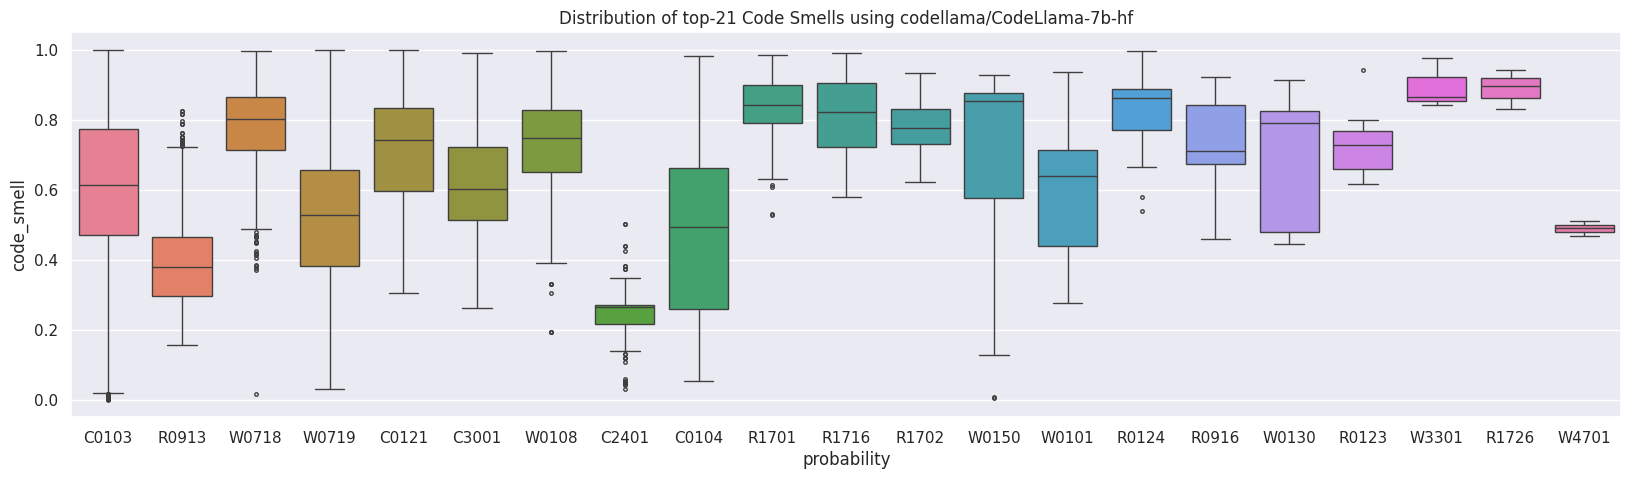

In [20]:
plt.figure(figsize=(20,5))
smells_distribution_plot = sns.boxplot(
        data=actual_probs_distributions,
        y="code_smell_actual_prob", 
        x="msg_id", 
        fliersize = 2.5, 
        #orient="vh",
        #notch=True,
        hue='msg_id'
)
smells_distribution_plot.set(xlabel=f"probability", ylabel="code_smell", title=f"Distribution of top-{params['top-k']} Code Smells using {params['causal_models'][params['current_model']]}")

[Text(0.5, 0, 'probability'),
 Text(0, 0.5, 'code_smell'),
 Text(0.5, 1.0, 'Distribution [s-normal] of top-21 Code Smells using codellama/CodeLlama-7b-hf')]

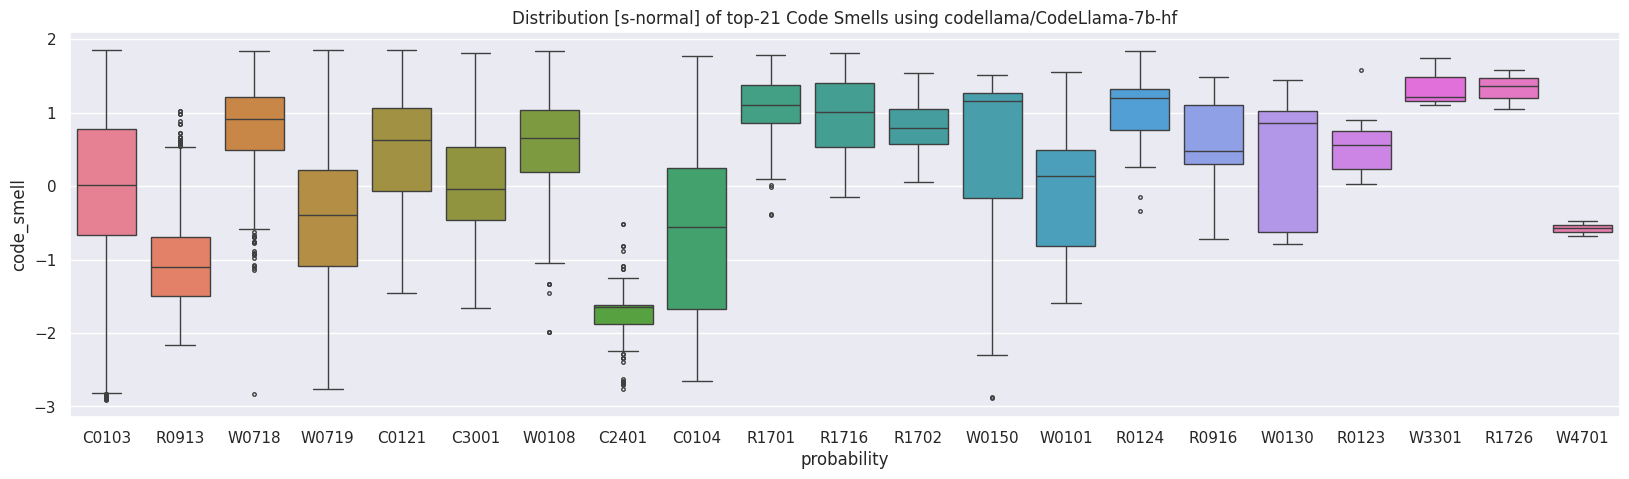

In [21]:
plt.figure(figsize=(20,5))
smells_distribution_plot = sns.boxplot(
        data=actual_probs_distributions_snormal,
        y="code_smell_actual_prob", 
        x="msg_id", 
        fliersize = 2.5, 
        #orient="h",
        #notch=True,
        hue='msg_id'
)
smells_distribution_plot.set(xlabel=f"probability", ylabel="code_smell", title=f"Distribution [s-normal] of top-{params['top-k']} Code Smells using {params['causal_models'][params['current_model']]}")

[Text(0.5, 0, 'probability'),
 Text(0, 0.5, 'code_smell'),
 Text(0.5, 1.0, 'Distribution [boxcox] of top-21 Code Smells using codellama/CodeLlama-7b-hf')]

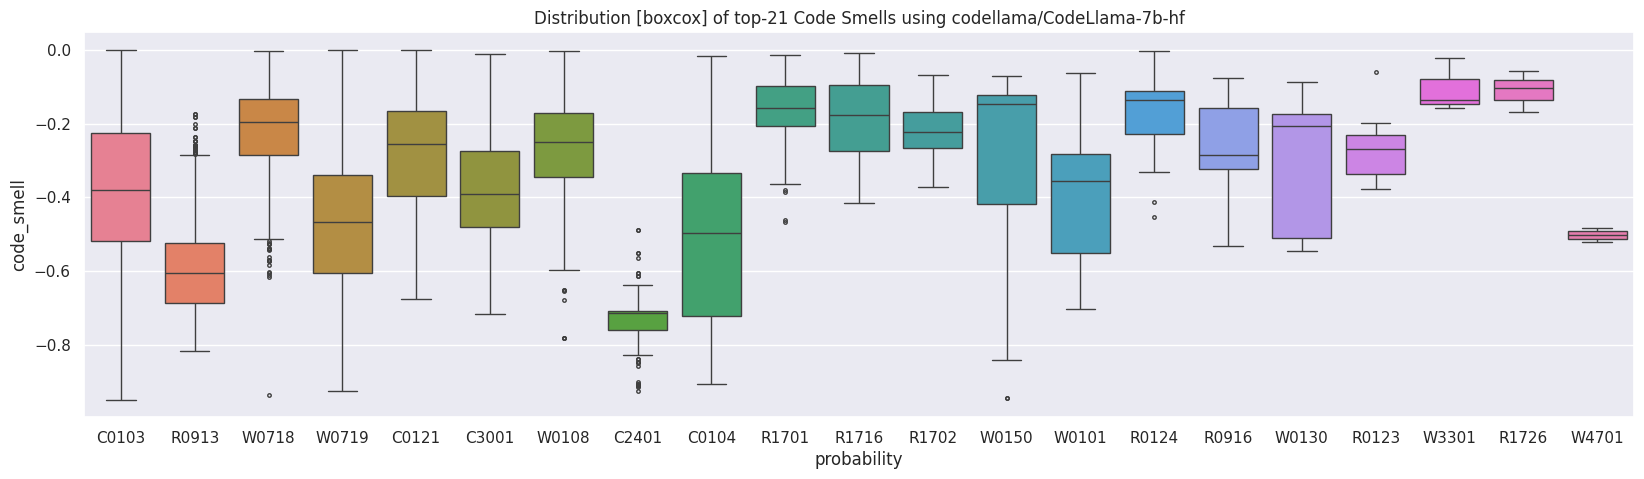

In [22]:
plt.figure(figsize=(20,5))
smells_distribution_plot = sns.boxplot(
        data=actual_probs_distributions_boxcox,
        y="code_smell_actual_prob", 
        x="msg_id", 
        fliersize = 2.5, 
        #orient="h",
        #notch=True,
        hue='msg_id'
)
smells_distribution_plot.set(xlabel=f"probability", ylabel="code_smell", title=f"Distribution [boxcox] of top-{params['top-k']} Code Smells using {params['causal_models'][params['current_model']]}")

[Text(0.5, 0, 'probability'),
 Text(0, 0.5, 'code_smell'),
 Text(0.5, 1.0, 'Boostrapped Distribution of top-21 Code Smells using codellama/CodeLlama-7b-hf')]

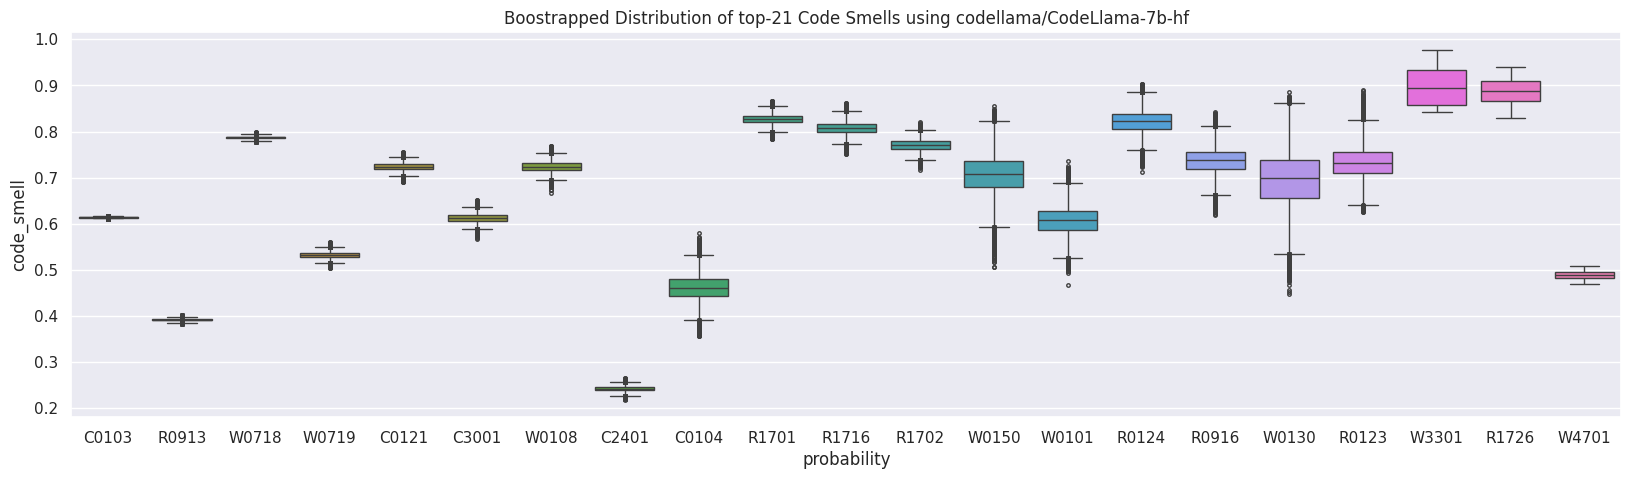

In [23]:
plt.figure(figsize=(20,5))
smells_distribution_plot = sns.boxplot(
        data=actual_probs_distributions_boostrapped,
        y="code_smell_actual_prob", 
        x="msg_id", 
        fliersize = 2.5, 
        #orient="h",
        #notch=True,
        hue='msg_id'
)
smells_distribution_plot.set(xlabel=f"probability", ylabel="code_smell", title=f"Boostrapped Distribution of top-{params['top-k']} Code Smells using {params['causal_models'][params['current_model']]}")

[Text(0.5, 0, 'probability'),
 Text(0, 0.5, 'code_smell'),
 Text(0.5, 1.0, 'Boostrapped Distribution [s-normal] of top-21 Code Smells using codellama/CodeLlama-7b-hf')]

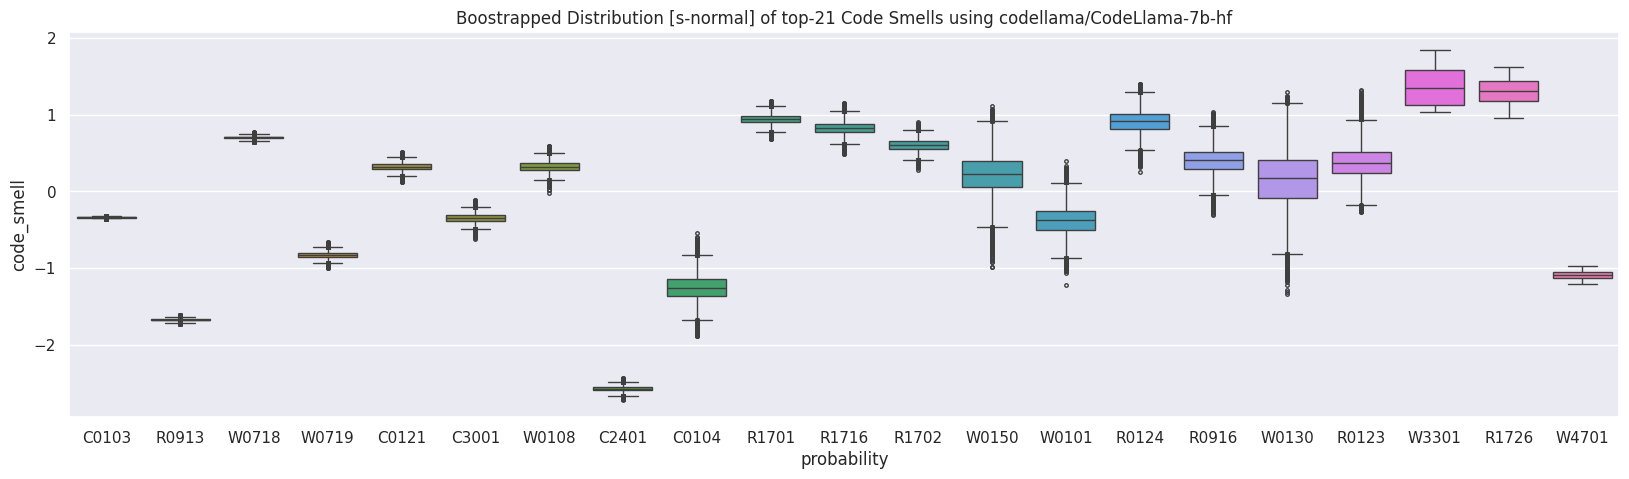

In [24]:
plt.figure(figsize=(20,5))
smells_distribution_plot = sns.boxplot(
        data=actual_probs_distributions_boostrapped_snormal,
        y="code_smell_actual_prob", 
        x="msg_id", 
        fliersize = 2.5, 
        #orient="h",
        #notch=True,
        hue='msg_id'
)
smells_distribution_plot.set(xlabel=f"probability", ylabel="code_smell", title=f"Boostrapped Distribution [s-normal] of top-{params['top-k']} Code Smells using {params['causal_models'][params['current_model']]}")

[Text(0.5, 0, 'probability'),
 Text(0, 0.5, 'code_smell'),
 Text(0.5, 1.0, 'Boostrapped Distribution [boxcox] of top-21 Code Smells using codellama/CodeLlama-7b-hf')]

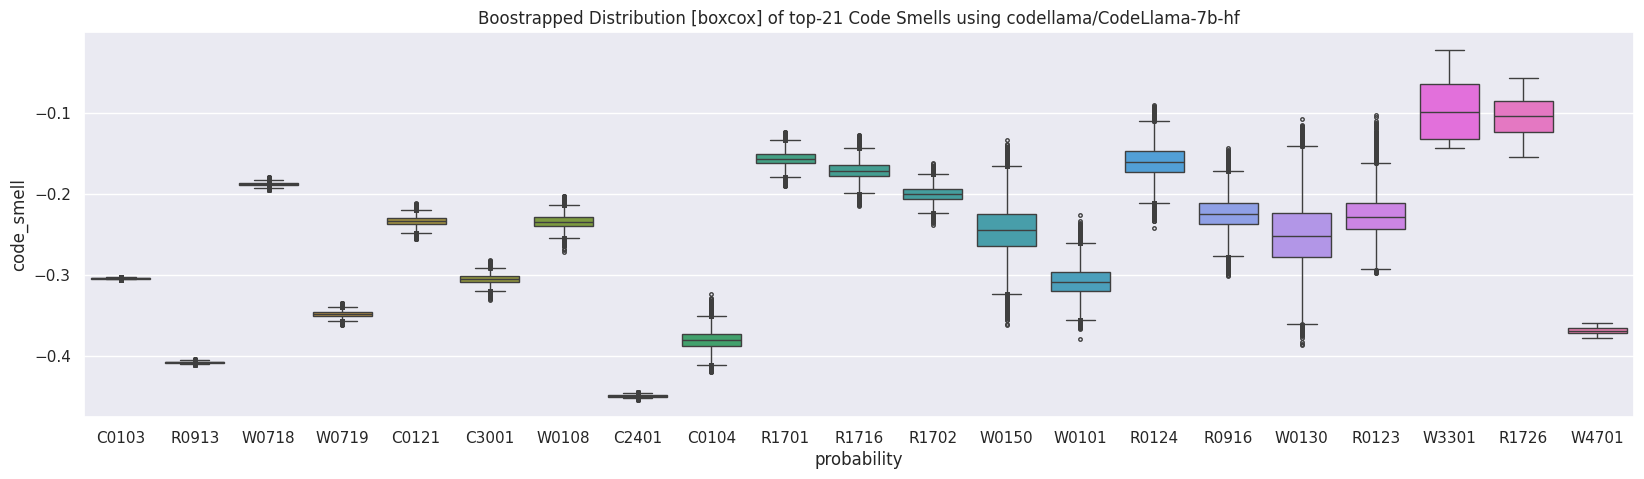

In [25]:
plt.figure(figsize=(20,5))
smells_distribution_plot = sns.boxplot(
        data=actual_probs_distributions_boostrapped_boxcox,
        y="code_smell_actual_prob", 
        x="msg_id", 
        fliersize = 2.5, 
        #orient="h",
        #notch=True,
        hue='msg_id'
)
smells_distribution_plot.set(xlabel=f"probability", ylabel="code_smell", title=f"Boostrapped Distribution [boxcox] of top-{params['top-k']} Code Smells using {params['causal_models'][params['current_model']]}")

#### Model Comparisson 

In [26]:
### M1
actual_probs_distributions_m1 = pd.read_csv(f"{params['output_path']}/M1_q_{params['quantization']}/actual_probs_distributions_top{params['top-k']}", index_col=0)
actual_probs_distributions_snormal_m1 = pd.read_csv(f"{params['output_path']}/M1_q_{params['quantization']}/actual_probs_distributions_snormal_top{params['top-k']}", index_col=0)
actual_probs_distributions_boxcox_m1 = pd.read_csv(f"{params['output_path']}/M1_q_{params['quantization']}/actual_probs_distributions_boxcox_top{params['top-k']}", index_col=0)

actual_probs_distributions_boostrapped_m1 = pd.read_csv(f"{params['output_path']}/M1_q_{params['quantization']}/actual_probs_distributions_boostrapped_top{params['top-k']}", index_col=0)
actual_probs_distributions_boostrapped_boxcox_m1 = pd.read_csv(f"{params['output_path']}/M1_q_{params['quantization']}/actual_probs_distributions_boostrapped_boxcox_top{params['top-k']}", index_col=0)
actual_probs_distributions_boostrapped_snormal_m1 = pd.read_csv(f"{params['output_path']}/M1_q_{params['quantization']}/actual_probs_distributions_boostrapped_snormal_top{params['top-k']}", index_col=0)

In [27]:
### M2
actual_probs_distributions_m2 = pd.read_csv(f"{params['output_path']}/M2_q_{params['quantization']}/actual_probs_distributions_top{params['top-k']}", index_col=0)
actual_probs_distributions_snormal_m2 = pd.read_csv(f"{params['output_path']}/M2_q_{params['quantization']}/actual_probs_distributions_snormal_top{params['top-k']}", index_col=0)
actual_probs_distributions_boxcox_m2 = pd.read_csv(f"{params['output_path']}/M2_q_{params['quantization']}/actual_probs_distributions_boxcox_top{params['top-k']}", index_col=0)

actual_probs_distributions_boostrapped_m2 = pd.read_csv(f"{params['output_path']}/M2_q_{params['quantization']}/actual_probs_distributions_boostrapped_top{params['top-k']}", index_col=0)
actual_probs_distributions_boostrapped_boxcox_m2 = pd.read_csv(f"{params['output_path']}/M2_q_{params['quantization']}/actual_probs_distributions_boostrapped_boxcox_top{params['top-k']}", index_col=0)
actual_probs_distributions_boostrapped_snormal_m2 = pd.read_csv(f"{params['output_path']}/M2_q_{params['quantization']}/actual_probs_distributions_boostrapped_snormal_top{params['top-k']}", index_col=0)

In [28]:
combined_distributions = pd.concat([actual_probs_distributions_m1,actual_probs_distributions_m2])
combined_distributions.reset_index(drop=True, inplace=True)

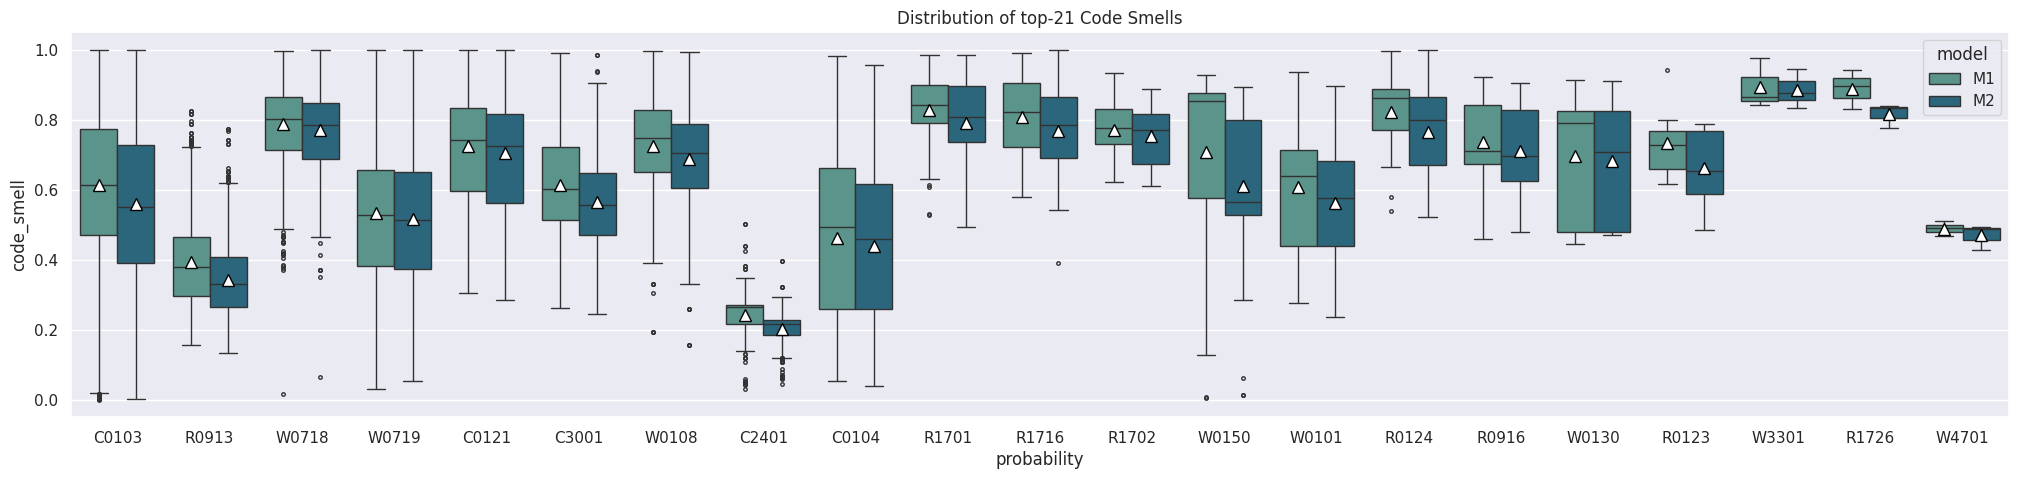

In [52]:
plt.figure(figsize=(25,5))
smells_distribution_plot = sns.boxplot(
        data=combined_distributions,
        y="code_smell_actual_prob", 
        x="msg_id", 
        fliersize = 2.5, 
        #orient="h",
        #notch=True,
        hue='model',
        palette='crest',
        showmeans = True, 
        meanprops={#'marker':'o',
                       'markerfacecolor':'white', 
                       'markeredgecolor':'black',
                       'markersize':'8'}
)


smells_distribution_plot.set(xlabel=f"probability", ylabel="code_smell", title=f"Distribution of top-{params['top-k']} Code Smells")
plt.show()

In [37]:
combined_distributions_boostrapped = pd.concat([actual_probs_distributions_boostrapped_m1,actual_probs_distributions_boostrapped_m2])
combined_distributions_boostrapped.reset_index(drop=True, inplace=True)

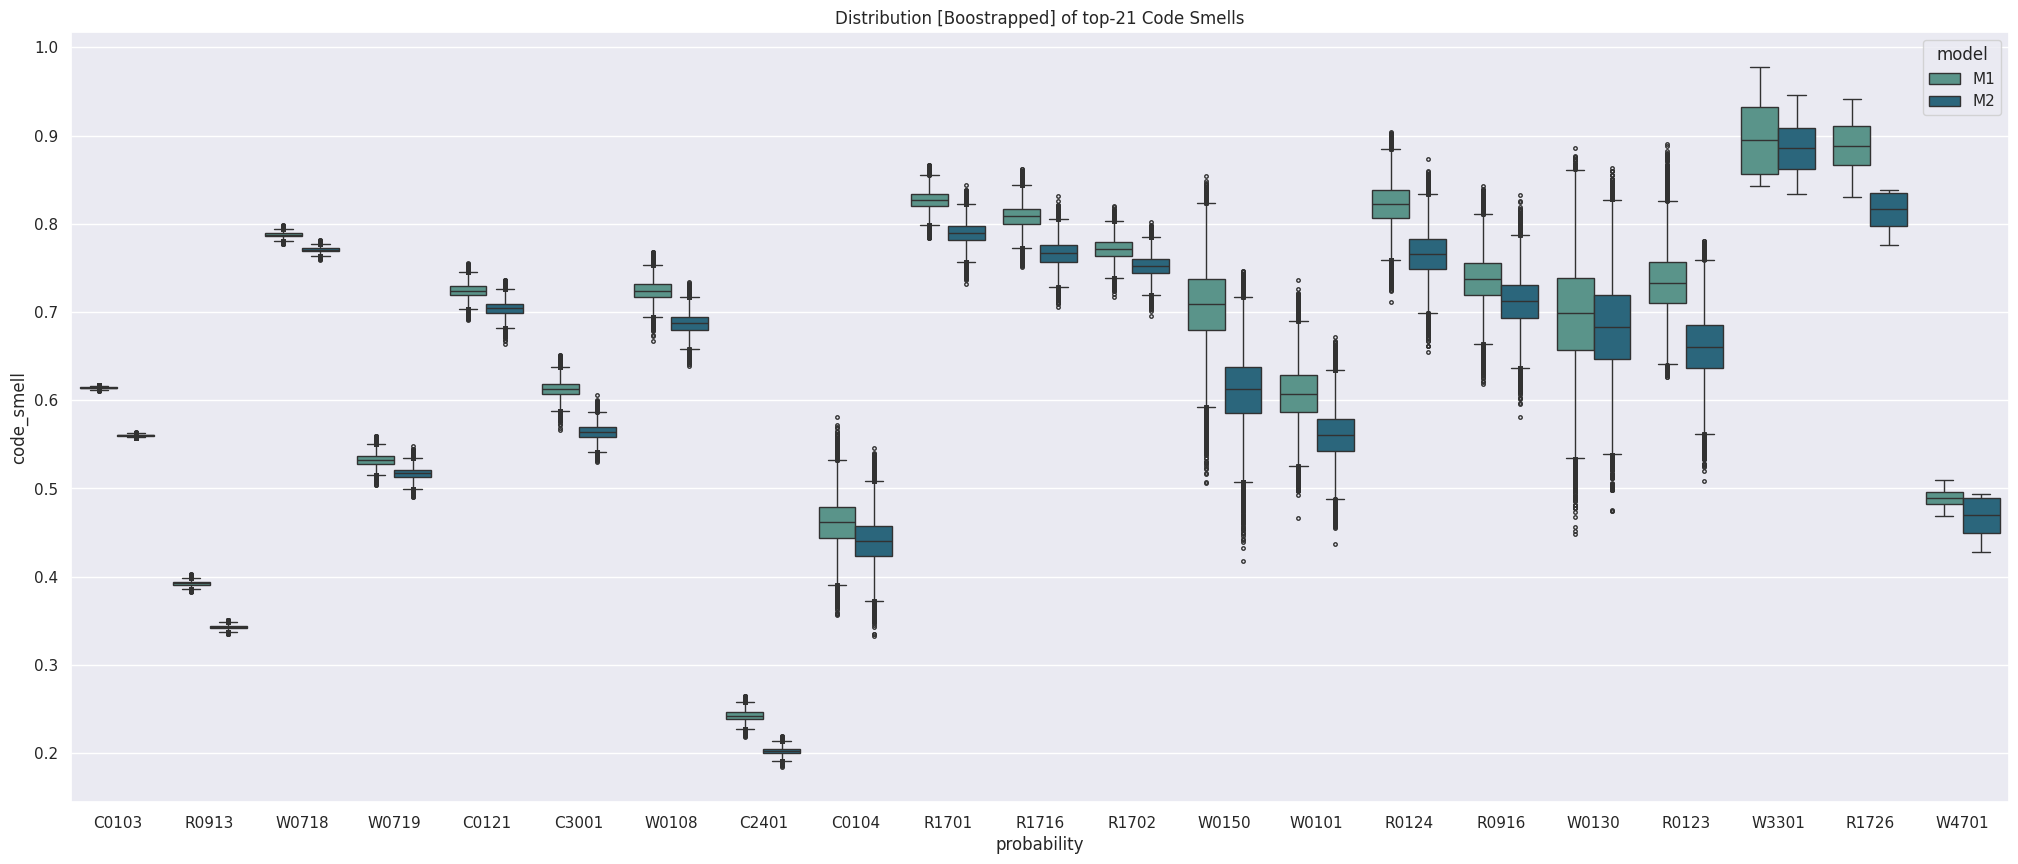

In [47]:
plt.figure(figsize=(25,10))
plt.grid(True, axis='y')
smells_distribution_plot = sns.boxplot(
        data=combined_distributions_boostrapped,
        y="code_smell_actual_prob", 
        x="msg_id", 
        fliersize = 2.5, 
        #orient="h",
        #notch=True,
        hue='model',
        palette='crest'
)
smells_distribution_plot.set(xlabel=f"probability", ylabel="code_smell", title=f"Distribution [Boostrapped] of top-{params['top-k']} Code Smells")
plt.show()